In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from tqdm.auto import tqdm

from utils import (
    configure_torch_cpu,
    make_synthetic_twolayer_worstcase_in_ball,
    perturb_twolayer_theta_entrywise,
    mu_f_twolayer,
    rademacher_twolayer_mc_entrywise,
    figures_dir,
    twolayer_weight_entrywise_bounds,
    twolayer_empirical_mse_grad_norm,
)

configure_torch_cpu()

In [2]:
teacher_noise_std = 0.0
m_entry = 1.0
seed = 42
base_n_features = 8

use_n_equal_h = True

evaluate_at_planted_optimum = True

eval_inward_scale = 0.25
eval_noise_scale = 0.10
eval_max_rel_output_shift = 0.02

n_sigma = 64
pgd_steps = 40
pgd_lr = 0.1

hidden_sizes = [4, 8, 12, 16, 24, 32]
m_samples_h = 512
variance_tries_h = 3
hessian_chunk_h = 64

In [3]:
torch.set_default_dtype(torch.float64)

h_arr = np.array(hidden_sizes, dtype=int)
ref_h4_raw = (m_entry * h_arr.astype(float)) ** 4
ref_norm_h = ref_h4_raw / ref_h4_raw[0]
ref_norm_h3 = (h_arr.astype(float) / h_arr[0]) ** 3

mu_all = np.zeros((len(hidden_sizes), variance_tries_h))
rad_all = np.zeros((len(hidden_sizes), variance_tries_h))
grad_norm_all = np.zeros((len(hidden_sizes), variance_tries_h))
max_w1_all = np.zeros((len(hidden_sizes), variance_tries_h))
max_w2_all = np.zeros((len(hidden_sizes), variance_tries_h))

for j, h in enumerate(tqdm(hidden_sizes, desc="width sweep [worst_case entrywise]")):
    n_current = h if use_n_equal_h else base_n_features
    for t in tqdm(range(variance_tries_h), leave=False, desc=f"h={h}"):
        run_seed = seed + 10_000 + 100 * j + t

        X_np, y_np, theta_teacher_np = make_synthetic_twolayer_worstcase_in_ball(
            n_current,
            m_samples_h,
            h,
            m_entry,
            noise_std=teacher_noise_std,
            seed=run_seed,
            return_theta_teacher=True,
        )
        if evaluate_at_planted_optimum:
            theta_eval_np = theta_teacher_np.copy()
        else:
            theta_eval_np = perturb_twolayer_theta_entrywise(
                theta_teacher_np,
                m_entry,
                inward_scale=eval_inward_scale,
                noise_scale=eval_noise_scale,
                seed=run_seed + 1,
                X_reference=X_np,
                n=n_current,
                h=h,
                max_relative_output_perturbation=eval_max_rel_output_shift,
            )

        X_t = torch.tensor(X_np, dtype=torch.float64)
        y_t = torch.tensor(y_np, dtype=torch.float64)
        theta_eval = torch.tensor(theta_eval_np, dtype=torch.float64, requires_grad=True)

        grad_norm_all[j, t] = twolayer_empirical_mse_grad_norm(theta_eval, X_t, y_t, n_current, h)

        mw1, mw2 = twolayer_weight_entrywise_bounds(theta_eval, n_current, h)
        max_w1_all[j, t] = mw1
        max_w2_all[j, t] = mw2
        mu_all[j, t] = mu_f_twolayer(
            theta_eval,
            X_t,
            y_t,
            n_current,
            h,
            hessian_chunk_size=hessian_chunk_h,
        )
        rad_all[j, t] = rademacher_twolayer_mc_entrywise(
            theta_eval,
            X_t,
            n_current,
            h,
            W_entry=m_entry,
            n_sigma=n_sigma,
            pgd_steps=pgd_steps,
            pgd_lr=pgd_lr,
            seed=run_seed,
        )

mu_mean = mu_all.mean(axis=1)
mu_std = mu_all.std(axis=1, ddof=1) if variance_tries_h > 1 else np.zeros(len(hidden_sizes))
rad_mean = rad_all.mean(axis=1)
rad_std = rad_all.std(axis=1, ddof=1) if variance_tries_h > 1 else np.zeros(len(hidden_sizes))
grad_mean = grad_norm_all.mean(axis=1)
M_hat = np.maximum(max_w1_all.mean(axis=1), max_w2_all.mean(axis=1))

results_h = {
    "mu_mean": mu_mean,
    "mu_std": mu_std,
    "rad_mean": rad_mean,
    "rad_std": rad_std,
    "grad_mean": grad_mean,
    "M_hat": M_hat,
    "mu_norm": mu_mean / mu_mean[0],
    "rad_norm": rad_mean / rad_mean[0],
    "ref_h4": mu_mean[0] * ref_h4_raw / ref_h4_raw[0],
    "ref_residual_gn": mu_mean[0] * ref_norm_h3,
    "ref_norm_h3": ref_norm_h3,
}

print("=" * 60)
mode_label = (
    "constructed worst-case data, evaluated at planted optimum"
    if evaluate_at_planted_optimum
    else "constructed worst-case data, evaluated in a small entrywise neighborhood"
)
print(mode_label)
print("widths:", h_arr)
print("mean mu_f:", results_h["mu_mean"])
print("mean R_hat:", results_h["rad_mean"])
print("mean grad norm:", results_h["grad_mean"])
print("effective M_hat:", results_h["M_hat"])
print("normalized h^4 reference:", ref_norm_h)

width sweep [worst_case entrywise]:   0%|          | 0/6 [00:00<?, ?it/s]

h=4:   0%|          | 0/3 [00:00<?, ?it/s]

h=8:   0%|          | 0/3 [00:00<?, ?it/s]

h=12:   0%|          | 0/3 [00:00<?, ?it/s]

h=16:   0%|          | 0/3 [00:00<?, ?it/s]

h=24:   0%|          | 0/3 [00:00<?, ?it/s]

h=32:   0%|          | 0/3 [00:00<?, ?it/s]

constructed worst-case data, evaluated at planted optimum
widths: [ 4  8 12 16 24 32]
mean mu_f: [  17.49358748  105.49902075  304.91892239  747.44814148 2209.96335334
 5200.6665801 ]
mean R_hat: [ 0.09074561  0.57564019  1.56263762  3.05808036  7.85411009 14.98061451]
mean grad norm: [9.15631846e-17 1.33918539e-15 1.96715998e-15 8.92251991e-15
 5.48691265e-14 1.58238538e-13]
effective M_hat: [1. 1. 1. 1. 1. 1.]
normalized h^4 reference: [1.000e+00 1.600e+01 8.100e+01 2.560e+02 1.296e+03 4.096e+03]


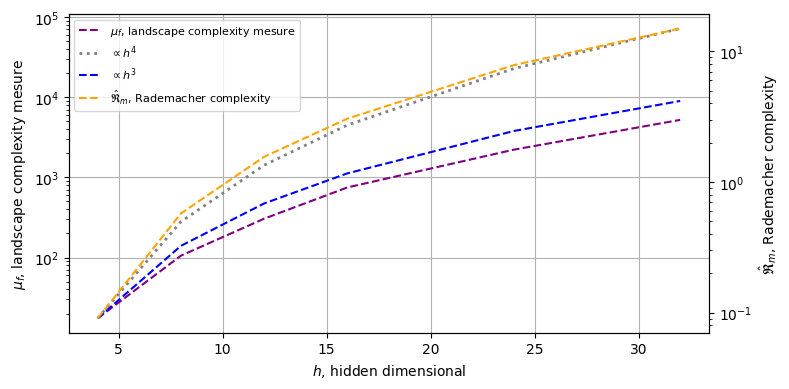

In [4]:
fig, ax_mu = plt.subplots(figsize=(8, 4))
ax_mu.set_yscale("log")
ax_mu.grid(True, which="major")

ax_mu.set_xlabel(r"$h$, hidden dimensional")
ax_mu.set_ylabel(r"$\mu_f$, landscape complexity mesure")
ax_mu.tick_params(axis="y")

ax_mu.plot(
    h_arr, results_h["mu_mean"], "--",
    color="purple", label=r"$\mu_f$, landscape complexity mesure"
)
ax_mu.plot(
    h_arr, results_h["ref_h4"], ":",
    color="gray", lw=2, label=r"$\propto h^4$",
)
ax_mu.plot(
    h_arr, results_h["ref_residual_gn"], "--",
    color="blue", label=r"$\propto h^3$",
)

ax_rad = ax_mu.twinx()
ax_rad.set_yscale("log")

ax_rad.set_ylabel(r"$\hat{\mathfrak{R}}_m$, Rademacher complexity")
ax_rad.tick_params(axis="y")

ax_rad.plot(
    h_arr, results_h["rad_mean"], "--",
    color="orange", label=r"$\hat{\mathfrak{R}}_m$, Rademacher complexity",
)

lines_l, lab_l = ax_mu.get_legend_handles_labels()
lines_r, lab_r = ax_rad.get_legend_handles_labels()
ax_mu.legend(lines_l + lines_r, lab_l + lab_r, loc="best", fontsize=8)
fig.tight_layout()
fig.savefig(figures_dir() / "exp03_twolayer_sweep_h.png", dpi=200, bbox_inches="tight")

plt.show()